# Seed set exploration

First look at `data/seed_set.csv` (293 hand-labeled verses: prophetic /
narrative / law-wisdom) before building any features. Goals:

1. Sanity-check label balance and verse-length distribution per class.
2. Spot-check a few verses per label.
3. Case study: compare Jude 1:14-15 against 1 Enoch 1:9 directly — the
   near-verbatim quotation documented in `docs/enoch-deep-dive.md`, and the
   only seed-set pair where the prophetic-register label is the canon's own
   judgment rather than this project's editorial call.


In [1]:
import os
import re

import matplotlib.pyplot as plt
import pandas as pd

REPO_ROOT = os.path.dirname(os.getcwd())
df = pd.read_csv(os.path.join(REPO_ROOT, "data", "seed_set.csv"))
df["word_count"] = df["text"].str.split().apply(len)
df.head()

,book,chapter,verse,ref,label,note,text,word_count
0,Isaiah,1,2,Isaiah 1:2,prophetic,"opening oracle, divine-speech formula","Hear, O heavens, and give ear, O earth: for th...",26
1,Isaiah,1,3,Isaiah 1:3,prophetic,"opening oracle, divine-speech formula","The ox knoweth his owner, and the ass his mast...",21
2,Isaiah,1,4,Isaiah 1:4,prophetic,"opening oracle, divine-speech formula","Ah sinful nation, a people laden with iniquity...",36
3,Isaiah,6,9,Isaiah 6:9,prophetic,call vision,"And he said, Go, and tell this people, Hear ye...",21
4,Isaiah,6,10,Isaiah 6:10,prophetic,call vision,"Make the heart of this people fat, and make th...",37


## Label balance

In [2]:
counts = df["label"].value_counts()
counts

label
narrative     125
prophetic     123
law-wisdom     73
Name: count, dtype: int64

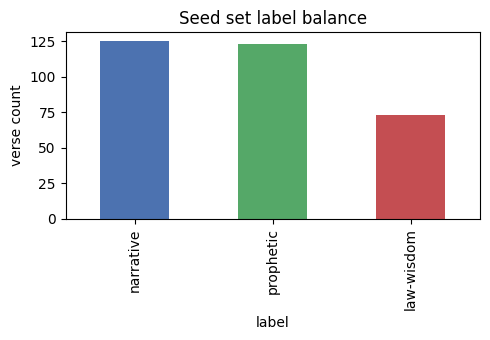

In [3]:
fig, ax = plt.subplots(figsize=(5, 3.5))
counts.plot(kind="bar", ax=ax, color=["#4C72B0", "#55A868", "#C44E52"])
ax.set_ylabel("verse count")
ax.set_title("Seed set label balance")
plt.tight_layout()
plt.show()

Not balanced (107 / 113 / 73) — expected for a hand-curated seed set built
from a fixed reference list rather than sampled to quota. Worth stratifying
or weighting once the classifier is trained (noted already in
`docs/seed-set.md`).

## Verse length by label

Word count per verse, since verse is the labeling unit.

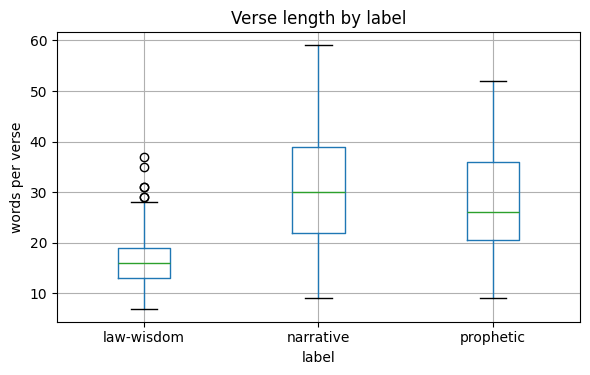

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
law-wisdom,73.0,17.356164,6.287929,7.0,13.0,16.0,19.0,37.0
narrative,125.0,31.224000,11.752737,9.0,22.0,30.0,39.0,59.0
prophetic,123.0,27.943089,10.181388,9.0,20.5,26.0,36.0,52.0


In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
df.boxplot(column="word_count", by="label", ax=ax)
ax.set_ylabel("words per verse")
ax.set_title("Verse length by label")
plt.suptitle("")
plt.tight_layout()
plt.show()

df.groupby("label")["word_count"].describe()

Law-wisdom verses run a bit longer on average (Leviticus's legal-clause
style, Proverbs 31's long acrostic lines) — worth remembering once
sentence/clause-length ends up as a stylometric feature; that's a book-level
effect as much as a genre one, and the seed set is small enough that a
couple of long chapters (Proverbs 31, Leviticus 19) can shift the whole
class average.

## Sample verses per label

In [5]:
for label in df["label"].unique():
    print(f"--- {label} ---")
    sample = df[df["label"] == label].sample(3, random_state=1)
    for _, row in sample.iterrows():
        print(f"{row['ref']:20s} {row['text']}")
    print()

--- prophetic ---
Ezekiel 37:4         Again he said unto me, Prophesy upon these bones, and say unto them, O ye dry bones, hear the word of the LORD.
Genesis 22:18        And in thy seed shall all the nations of the earth be blessed; because thou hast obeyed my voice.
Zephaniah 1:17       And I will bring distress upon men, that they shall walk like blind men, because they have sinned against the LORD: and their blood shall be poured out as dust, and their flesh as the dung.

--- narrative ---
Esther 2:18          Then the king made a great feast unto all his princes and his servants, even Esther’s feast; and he made a release to the provinces, and gave gifts, according to the state of the king.
Ruth 1:2             And the name of the man was Elimelech, and the name of his wife Naomi, and the name of his two sons Mahlon and Chilion, Ephrathites of Bethlehemjudah. And they came into the country of Moab, and continued there.
Ruth 1:5             And Mahlon and Chilion died also both of

## Case study: Jude 1:14-15 vs. 1 Enoch 1:9

Jude quotes 1 Enoch almost word for word and calls it "prophesied" — see
`docs/enoch-deep-dive.md`. Pull both texts directly and compare.

In [6]:
jude = df[df["ref"].str.startswith("Jude")]["text"].str.cat(sep=" ")
print("Jude 1:14-15 (KJV):")
print(jude)

Jude 1:14-15 (KJV):
And Enoch also, the seventh from Adam, prophesied of these, saying, Behold, the Lord cometh with ten thousands of his saints, To execute judgment upon all, and to convince all that are ungodly among them of all their ungodly deeds which they have ungodly committed, and of all their hard speeches which ungodly sinners have spoken against him.


In [7]:
enoch_path = os.path.join(REPO_ROOT, "data", "transfer", "1_enoch.txt")
with open(enoch_path, encoding="utf-8") as f:
    enoch_lines = f.readlines()

# Verse 9 is the last verse of Chapter I, so it runs from "And behold! He
# cometh" up to the "CHAPTER II" heading (there's no "10." to stop at).
start = next(i for i, ln in enumerate(enoch_lines) if ln.strip().startswith("9. And behold"))
end = next(i for i, ln in enumerate(enoch_lines[start:], start) if "CHAPTER" in ln)
enoch_v9 = " ".join(ln.strip().strip("⌈⌉⌊⌋") for ln in enoch_lines[start:end] if ln.strip())
print("1 Enoch 1:9 (Charles, 1913):")
print(enoch_v9)

1 Enoch 1:9 (Charles, 1913):
9. And behold! He cometh with ten thousands of  His  holy ones To execute judgement upon all, And to destroy  all  the ungodly: And to convict all flesh Of all the works  of their ungodliness  which they have ungodly committed, And of all the hard things which ungodly sinners  have spoken  against Him.


In [8]:
def normalize(s):
    return re.sub(r"[^a-z\s]", "", s.lower()).split()

jude_words = set(normalize(jude))
enoch_words = set(normalize(enoch_v9))
overlap = jude_words & enoch_words
print(f"Jude 1:14-15 unique words:   {len(jude_words)}")
print(f"1 Enoch 1:9 unique words:    {len(enoch_words)}")
print(f"Shared:                      {len(overlap)}")
print(f"Jaccard similarity:          {len(overlap) / len(jude_words | enoch_words):.2f}")
print(sorted(overlap))

Jude 1:14-15 unique words:   42
1 Enoch 1:9 unique words:    34
Shared:                      24
Jaccard similarity:          0.46
['against', 'all', 'and', 'behold', 'cometh', 'committed', 'execute', 'hard', 'have', 'him', 'his', 'of', 'sinners', 'spoken', 'ten', 'the', 'their', 'they', 'thousands', 'to', 'ungodly', 'upon', 'which', 'with']


High word overlap between a NT epistle verse and a pseudepigraphal
apocalyptic text is exactly what you'd expect from a direct quotation, and
confirms the pair is usable as a controlled same-register anchor: whatever
the eventual feature set says about "prophetic register," these two verses
should score close to each other, since they're substantially the same
text. If they don't, that's a signal the feature set is picking up on
something other than register (e.g. translator idiom — KJV vs. Charles
1913 — rather than genre).